In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"

DATA_FILE = DATA_DIR / "dataSet_withFeatures.csv"
LABEL_FILE = DATA_DIR / "dataSet_withFeatures_labels.csv"

data = pd.read_csv(DATA_FILE, header=None)
labels = pd.read_csv(LABEL_FILE, header=None).iloc[:, 0]

print("Data:", data.shape)
print("Labels:", labels.shape)

Data: (5990, 448)
Labels: (5990,)


In [4]:
X = data.iloc[:, :447].copy()
y = labels.astype(str).str.strip().copy()

print("X:", X.shape)
print("y:", y.shape)

X: (5990, 447)
y: (5990,)


In [5]:
X_tactile = X.iloc[:, :414].to_numpy(dtype=np.float32)
X_features = X.iloc[:, 414:447].to_numpy(dtype=np.float32)

print("Tactile:", X_tactile.shape)
print("Features:", X_features.shape)

Tactile: (5990, 414)
Features: (5990, 33)


In [6]:
label_map = {
    "asphalt": 0,
    "cork": 1,
    "grass": 2,
    "gravel": 3,
    "lab": 4,
    "laminate_wood": 5,
    "pebble": 6,
    "sand": 7
}
y_encoded = y.map(label_map)

print(y_encoded.head())
print("\nMissing encoded labels:", y_encoded.isna().sum())

0    0
1    0
2    0
3    0
4    0
Name: 0, dtype: int64

Missing encoded labels: 0


In [7]:
print(
    pd.DataFrame({
        "terrain": y,
        "encoded": y_encoded
    }).drop_duplicates().sort_values("encoded")
)

            terrain  encoded
0           asphalt        0
404            cork        1
1136          grass        2
1837         gravel        3
2324            lab        4
2725  laminate_wood        5
3095         pebble        6
3820           sand        7


In [8]:
X_tactile_train, X_tactile_temp, \
X_features_train, X_features_temp, \
y_train, y_temp = train_test_split(
    X_tactile,
    X_features,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

In [9]:
X_tactile_val, X_tactile_test, \
X_features_val, X_features_test, \
y_val, y_test = train_test_split(
    X_tactile_temp,
    X_features_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [11]:
print("Training:", len(y_train))
print("Validation:", len(y_val))
print("Test:", len(y_test))

Training: 4193
Validation: 898
Test: 899


In [13]:
def show_distribution(y, name):
    counts = pd.Series(y).value_counts().sort_index()

    print(f"\n{name}")
    print(counts)

show_distribution(y_train, "Training")
show_distribution(y_val, "Validation")
show_distribution(y_test, "Test")


Training
0
0    559
1    512
2    491
3    509
4    542
5    540
6    508
7    532
Name: count, dtype: int64

Validation
0
0    119
1    110
2    105
3    109
4    116
5    116
6    109
7    114
Name: count, dtype: int64

Test
0
0    120
1    110
2    105
3    109
4    117
5    116
6    108
7    114
Name: count, dtype: int64


In [14]:
X_tactile_train = X_tactile_train.reshape(-1, 6, 69)
X_tactile_val = X_tactile_val.reshape(-1, 6, 69)
X_tactile_test = X_tactile_test.reshape(-1, 6, 69)

print(X_tactile_train.shape)

(4193, 6, 69)


In [15]:
tactile_mean = X_tactile_train.mean(axis=(0, 2), keepdims=True)
tactile_std = X_tactile_train.std(axis=(0, 2), keepdims=True)

print("Mean shape:", tactile_mean.shape)
print("Std shape:", tactile_std.shape)

Mean shape: (1, 6, 1)
Std shape: (1, 6, 1)


In [16]:
X_tactile_train = (
    X_tactile_train - tactile_mean
) / tactile_std

X_tactile_val = (
    X_tactile_val - tactile_mean
) / tactile_std

X_tactile_test = (
    X_tactile_test - tactile_mean
) / tactile_std

print("Train mean:", X_tactile_train.mean())
print("Train std:", X_tactile_train.std())

Train mean: -2.3065278e-08
Train std: 1.0


In [17]:
feature_scaler = StandardScaler()

X_features_train = feature_scaler.fit_transform(
    X_features_train
)

X_features_val = feature_scaler.transform(
    X_features_val
)

X_features_test = feature_scaler.transform(
    X_features_test
)

print(
    "Training feature mean:",
    X_features_train.mean()
)

print(
    "Training feature std:",
    X_features_train.std()
)

Training feature mean: -1.3674232e-08
Training feature std: 1.0


In [18]:
y_train = y_train.to_numpy(dtype=np.int64)
y_val = y_val.to_numpy(dtype=np.int64)
y_test = y_test.to_numpy(dtype=np.int64)

print("X tactile train:", X_tactile_train.shape)
print("X features train:", X_features_train.shape)
print("y train:", y_train.shape)

print("X tactile val:", X_tactile_val.shape)
print("X features val:", X_features_val.shape)
print("y val:", y_val.shape)

print("X tactile test:", X_tactile_test.shape)
print("X features test:", X_features_test.shape)
print("y test:", y_test.shape)

X tactile train: (4193, 6, 69)
X features train: (4193, 33)
y train: (4193,)
X tactile val: (898, 6, 69)
X features val: (898, 33)
y val: (898,)
X tactile test: (899, 6, 69)
X features test: (899, 33)
y test: (899,)


In [19]:
# Final preprocessing verification

print("===== SHAPES =====")
print("Tactile train:", X_tactile_train.shape)
print("Tactile val:  ", X_tactile_val.shape)
print("Tactile test: ", X_tactile_test.shape)

print("\nFeatures train:", X_features_train.shape)
print("Features val:  ", X_features_val.shape)
print("Features test: ", X_features_test.shape)

print("\ny train:", y_train.shape)
print("y val:  ", y_val.shape)
print("y test: ", y_test.shape)


print("\n===== CLASS COUNTS =====")
print("Train:", np.bincount(y_train))
print("Val:  ", np.bincount(y_val))
print("Test: ", np.bincount(y_test))


print("\n===== NaN CHECK =====")
print("Tactile train NaN:", np.isnan(X_tactile_train).sum())
print("Features train NaN:", np.isnan(X_features_train).sum())

print("\n===== INFINITY CHECK =====")
print("Tactile train Inf:", np.isinf(X_tactile_train).sum())
print("Features train Inf:", np.isinf(X_features_train).sum())

===== SHAPES =====
Tactile train: (4193, 6, 69)
Tactile val:   (898, 6, 69)
Tactile test:  (899, 6, 69)

Features train: (4193, 33)
Features val:   (898, 33)
Features test:  (899, 33)

y train: (4193,)
y val:   (898,)
y test:  (899,)

===== CLASS COUNTS =====
Train: [559 512 491 509 542 540 508 532]
Val:   [119 110 105 109 116 116 109 114]
Test:  [120 110 105 109 117 116 108 114]

===== NaN CHECK =====
Tactile train NaN: 0
Features train NaN: 0

===== INFINITY CHECK =====
Tactile train Inf: 0
Features train Inf: 0


In [22]:
# ============================================
# SVM BASELINE PREPARATION
# ============================================

# Flatten tactile data
X_tactile_train_flat = X_tactile_train.reshape(X_tactile_train.shape[0], -1)
X_tactile_val_flat = X_tactile_val.reshape(X_tactile_val.shape[0], -1)
X_tactile_test_flat = X_tactile_test.reshape(X_tactile_test.shape[0], -1)

print("Tactile flattened:")
print("Train:", X_tactile_train_flat.shape)
print("Val:  ", X_tactile_val_flat.shape)
print("Test: ", X_tactile_test_flat.shape)

Tactile flattened:
Train: (4193, 414)
Val:   (898, 414)
Test:  (899, 414)


In [23]:
X_svm_train = np.concatenate(
    [X_tactile_train_flat, X_features_train],
    axis=1
)

X_svm_val = np.concatenate(
    [X_tactile_val_flat, X_features_val],
    axis=1
)

X_svm_test = np.concatenate(
    [X_tactile_test_flat, X_features_test],
    axis=1
)

print("\nSVM input:")
print("Train:", X_svm_train.shape)
print("Val:  ", X_svm_val.shape)
print("Test: ", X_svm_test.shape)


SVM input:
Train: (4193, 447)
Val:   (898, 447)
Test:  (899, 447)


In [28]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    random_state=42
)

svm_model.fit(X_svm_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [29]:
y_val_pred = svm_model.predict(X_svm_val)

val_accuracy = accuracy_score(y_val, y_val_pred)

print(f"Validation Accuracy: {val_accuracy:.4f}")

Validation Accuracy: 0.6693


In [30]:
# Get terrain names in encoded-label order
terrain_classes = (
    pd.DataFrame({
        "terrain": y,
        "encoded": y_encoded
    })
    .drop_duplicates()
    .sort_values("encoded")["terrain"]
    .tolist()
)

print("\nClassification Report:")

print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=terrain_classes
    )
)


Classification Report:
               precision    recall  f1-score   support

      asphalt       0.54      0.60      0.57       119
         cork       0.50      0.53      0.51       110
        grass       0.80      0.74      0.77       105
       gravel       0.69      0.64      0.66       109
          lab       0.55      0.63      0.59       116
laminate_wood       0.71      0.53      0.61       116
       pebble       0.69      0.72      0.70       109
         sand       0.94      0.97      0.96       114

     accuracy                           0.67       898
    macro avg       0.68      0.67      0.67       898
 weighted avg       0.68      0.67      0.67       898



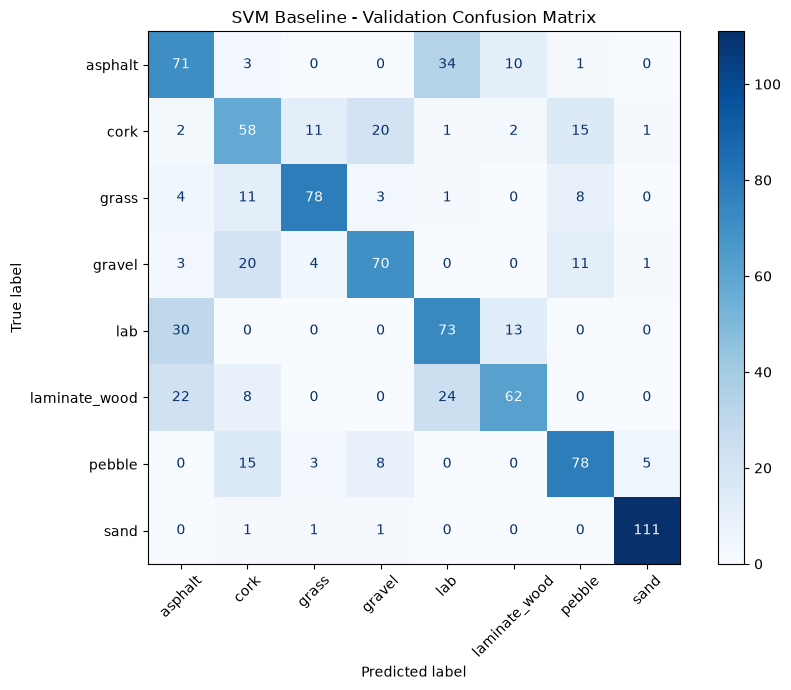

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_val, y_val_pred)

fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=terrain_classes
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

ax.set_title("SVM Baseline - Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [32]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.001]
}

svm_grid = GridSearchCV(
    estimator=SVC(kernel="rbf"),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_svm_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strat

In [34]:
# Evaluate tuned SVM on validation set

svm_tuned = svm_grid.best_estimator_

y_val_pred_tuned = svm_tuned.predict(X_svm_val)

tuned_val_accuracy = accuracy_score(
    y_val,
    y_val_pred_tuned
)

print(f"Tuned SVM Validation Accuracy: {tuned_val_accuracy:.4f}")

print("\nTuned SVM Classification Report:")

print(
    classification_report(
        y_val,
        y_val_pred_tuned,
        target_names=terrain_classes
    )
)

Tuned SVM Validation Accuracy: 0.7160

Tuned SVM Classification Report:
               precision    recall  f1-score   support

      asphalt       0.59      0.70      0.64       119
         cork       0.56      0.59      0.57       110
        grass       0.78      0.76      0.77       105
       gravel       0.74      0.67      0.71       109
          lab       0.63      0.58      0.60       116
laminate_wood       0.73      0.71      0.72       116
       pebble       0.77      0.75      0.76       109
         sand       0.97      0.97      0.97       114

     accuracy                           0.72       898
    macro avg       0.72      0.72      0.72       898
 weighted avg       0.72      0.72      0.72       898



In [35]:
import joblib

joblib.dump(
    svm_tuned,
    "../models/svm_447.pkl"
)

print("SVM-447 model saved.")

SVM-447 model saved.


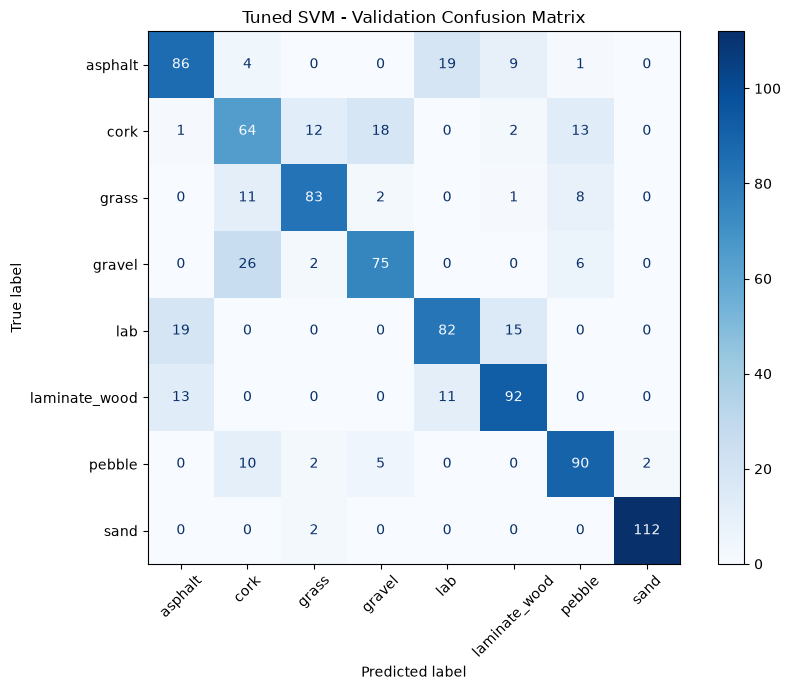

In [38]:
# Tuned SVM confusion matrix

cm_tuned = confusion_matrix(
    y_val,
    y_val_pred_tuned
)

fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=terrain_classes
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

ax.set_title("Tuned SVM - Validation Confusion Matrix")

plt.tight_layout()
plt.show()

In [39]:
# ============================================
# FINAL SVM TEST EVALUATION
# ============================================

y_test_pred_svm = svm_tuned.predict(X_svm_test)

test_accuracy_svm = accuracy_score(
    y_test,
    y_test_pred_svm
)

print(f"SVM Test Accuracy: {test_accuracy_svm:.4f}")
print("\nSVM Test Classification Report:")

print(
    classification_report(
        y_test,
        y_test_pred_svm,
        target_names=terrain_classes
    )
)

SVM Test Accuracy: 0.7608

SVM Test Classification Report:
               precision    recall  f1-score   support

      asphalt       0.71      0.71      0.71       120
         cork       0.62      0.64      0.63       110
        grass       0.79      0.80      0.79       105
       gravel       0.75      0.69      0.72       109
          lab       0.69      0.69      0.69       117
laminate_wood       0.83      0.83      0.83       116
       pebble       0.73      0.78      0.75       108
         sand       0.98      0.96      0.97       114

     accuracy                           0.76       899
    macro avg       0.76      0.76      0.76       899
 weighted avg       0.76      0.76      0.76       899



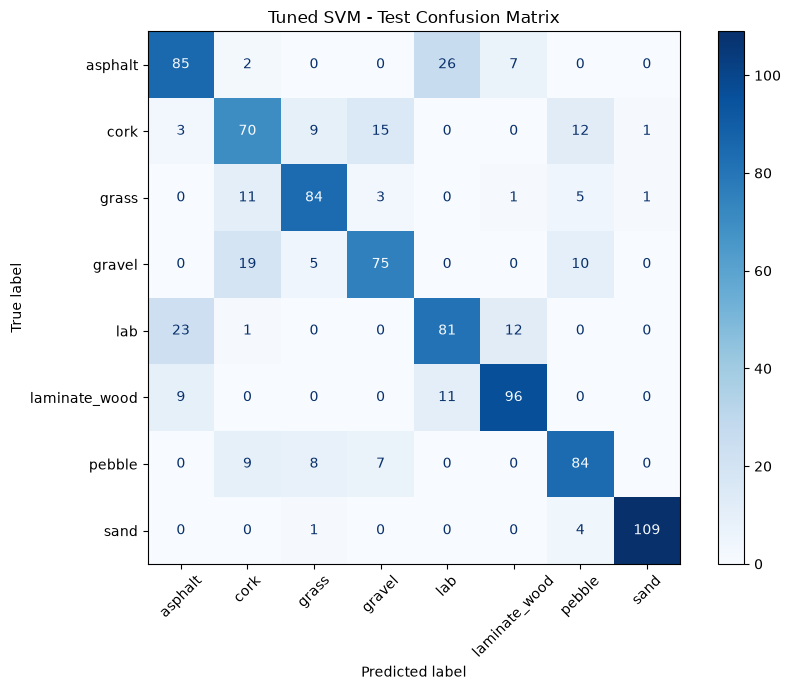

In [40]:
cm_svm_test = confusion_matrix(
    y_test,
    y_test_pred_svm
)

fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm_test,
    display_labels=terrain_classes
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

ax.set_title("Tuned SVM - Test Confusion Matrix")

plt.tight_layout()
plt.show()